In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import ShuffleSplit, cross_val_score
from sklearn.pipeline import Pipeline

from mne import Epochs, pick_types
from mne.channels import make_standard_montage
from mne.datasets import eegbci
from mne.decoding import CSP
from mne.io import concatenate_raws, read_raw_edf

In [71]:
print(__doc__)

# #############################################################################
# # Set parameters and read data

# avoid classification of evoked responses by using epochs that start 1s after
# cue onset.
tmin, tmax = -1.0, 4.0
subjects = 6
runs = [5, 9, 13]  # motor imagery: hands vs feet

raw_fnames = eegbci.load_data(subjects, runs)
raw = concatenate_raws([read_raw_edf(f, preload=True) for f in raw_fnames])
eegbci.standardize(raw)  # set channel names
montage = make_standard_montage("standard_1005")
raw.set_montage(montage)
print(raw.annotations)
raw.annotations.rename(dict(T1="left", T2="right"))  # as documented on PhysioNet
raw.set_eeg_reference(projection=True)

# Apply band-pass filter
raw.filter(7.0, 30.0, fir_design="firwin", skip_by_annotation="edge")

picks = pick_types(raw.info, meg=False, eeg=True, stim=False, eog=False, exclude="bads")

# Read epochs (train will be done only between 1 and 2s)
# Testing will be done with a running classifier
epochs = Epochs(
    raw,
    event_id=["left", "right"],
    tmin=tmin,
    tmax=tmax,
    proj=True,
    picks=picks,
    baseline=None,
    preload=True,
)
epochs_data = epochs.get_data()
epochs_train = epochs.copy().crop(tmin=1.0, tmax=2.0)
labels = epochs.events[:, -1] - 2


Note: all executions are function-scoped as we do not assume the code below executes in an isolated kernel environment.



Download complete in 39s (7.3 MB)
Extracting EDF parameters from /home/neuron/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S006/S006R05.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Extracting EDF parameters from /home/neuron/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S006/S006R09.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Extracting EDF parameters from /home/neuron/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S006/S006R13.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
<Annotations | 94 segments: BAD boundary (2), EDGE boundary (2), T0 (45), ...>
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference proje

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    0.0s finished


In [24]:
data_file_path = "../../data/20250604/processed/20250604_1_ishii_ica_epochs.pkl"
# data_file_path = "data/20250604/processed/20250604_2_Ishii_ica_epochs.pkl"

import pickle

print(__doc__)

# pickleのEEGデータを読み込む
with open(data_file_path, 'rb') as f:
    data = pickle.load(f)

epochs = data['epochs'] # エポックデータ
labels = data['labels']  # ラベル
# drop_indices = data['drop_indices']  # 除外されたエポックのインデックス

epochs.filter(7.0, 30.0, fir_design="firwin", skip_by_annotation="edge")  # バンドパスフィルタを適用
epochs.resample(500)

epochs_data = epochs.get_data(copy=True)  # エポックデータをリスト形式で取得
# データ型をdouble precision floatに変換
epochs_data = epochs_data.astype(np.float64)
print(epochs.info['ch_names'])  # サンプリング周波数を表示


Note: all executions are function-scoped as we do not assume the code below executes in an isolated kernel environment.

Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 7.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 6.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 4125 samples (1.650 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 647 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 881 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done 1151 tasks      | elapsed:    0.7s
[Parallel(n_jobs=1)]: Done 1457 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done 1799 tasks      | elapsed:    1.2s
[Parallel(n_jobs=1)]: Done 2177 tasks      | elapsed:    1.4s
[Parallel(n_jobs=1)]: Done 2591 tasks      | elapsed:    1.7s
[Parallel(n_jobs=1)]: Done 3041 tasks      | elapsed:    2.1s
[Parallel(n_jobs=1)]: Done 3527 tasks      | elapsed:    2.4s
[Parallel(n_jobs=1)]: Done 3780 out of 3780 | elapsed:    2.6s finished


['Fp1', 'Fz', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'TP9', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'TP10', 'CP6', 'CP2', 'Cz', 'C4', 'T8', 'FT10', 'FC6', 'FC2', 'F4', 'F8', 'Fp2', 'AF7', 'AF3', 'AFz', 'F1', 'F5', 'FT7', 'FC3', 'C1', 'C5', 'TP7', 'CP3', 'P1', 'P5', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'P6', 'P2', 'CPz', 'CP4', 'TP8', 'C6', 'C2', 'FC4', 'FT8', 'F6', 'AF8', 'AF4', 'F2']


In [ ]:
import csv
import mne
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
import pickle
from pathlib import Path

file_path = "../../data/20250604/20250604_1_ishii.vhdr"
# .vhdrファイルを指定してEEGデータを読み込む
raw = mne.io.read_raw_brainvision(file_path, preload=True)
# rename_mapping = {ch: ELECTRODE_NAMES[i] for i, ch in enumerate(raw.ch_names)}
# raw.rename_channels(rename_mapping)
raw.set_montage('easycap-M1')
raw.filter(l_freq=7, h_freq=30)
raw.info

Extracting parameters from ../../data/20250604/20250604_1_ishii.vhdr...
Setting channel info structure...
Reading 0 ... 1690649  =      0.000 ...   676.260 secs...


/tmp/ipykernel_1347/633957406.py:11: RuntimeWarning: Online software filter detected. Using software filter settings and ignoring hardware values
  raw = mne.io.read_raw_brainvision(file_path, preload=True)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 7.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 6.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 4125 samples (1.650 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.


[Parallel(n_jobs=1)]: Done  63 out of  63 | elapsed:    2.8s finished


ValueError: Missing channels from ch_names required by include:
['Iz']

len(task_sequence)=60
Used Annotations descriptions: ['New Segment/', 'Stimulus/S 14', 'Stimulus/S 15']
event_timestamps: [  61953   84992  108801  132608  156416  180224  204545  227583  251904
  275457  299776  322560  345611  368640  392449  416255  439294  462346
  485885  510721  582959  607278  630831  654124  676908  700460  724525
  747308  770610  793387  816431  840491  865080  888619  913197  937519
  960812  983594 1007928 1031210 1086766 1087277 1087786 1088297 1088809
 1090859 1091369 1092137 1092650 1093161 1169962 1193258 1217068 1240619
 1264943 1288232 1311529 1336111 1359912 1384241 1408808 1432875 1457191
 1481008 1504295 1527848 1551145 1573933 1597997 1622313] 70
Not setting metadata
60 matching events found
Setting baseline interval to [-1.0, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 60 events and 12501 original time points ...
0 bad epochs dropped


/home/neuron/Documents/mi-analyze/.venv/lib/python3.12/site-packages/mne/viz/_mpl_figure.py:2150: UserWarning: Glyph 181 (\N{MICRO SIGN}) missing from font(s) IPAexGothic.
  self.canvas.draw_idle()
/home/neuron/Documents/mi-analyze/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 181 (\N{MICRO SIGN}) missing from font(s) IPAexGothic.
  fig.canvas.print_figure(bytes_io, **kw)


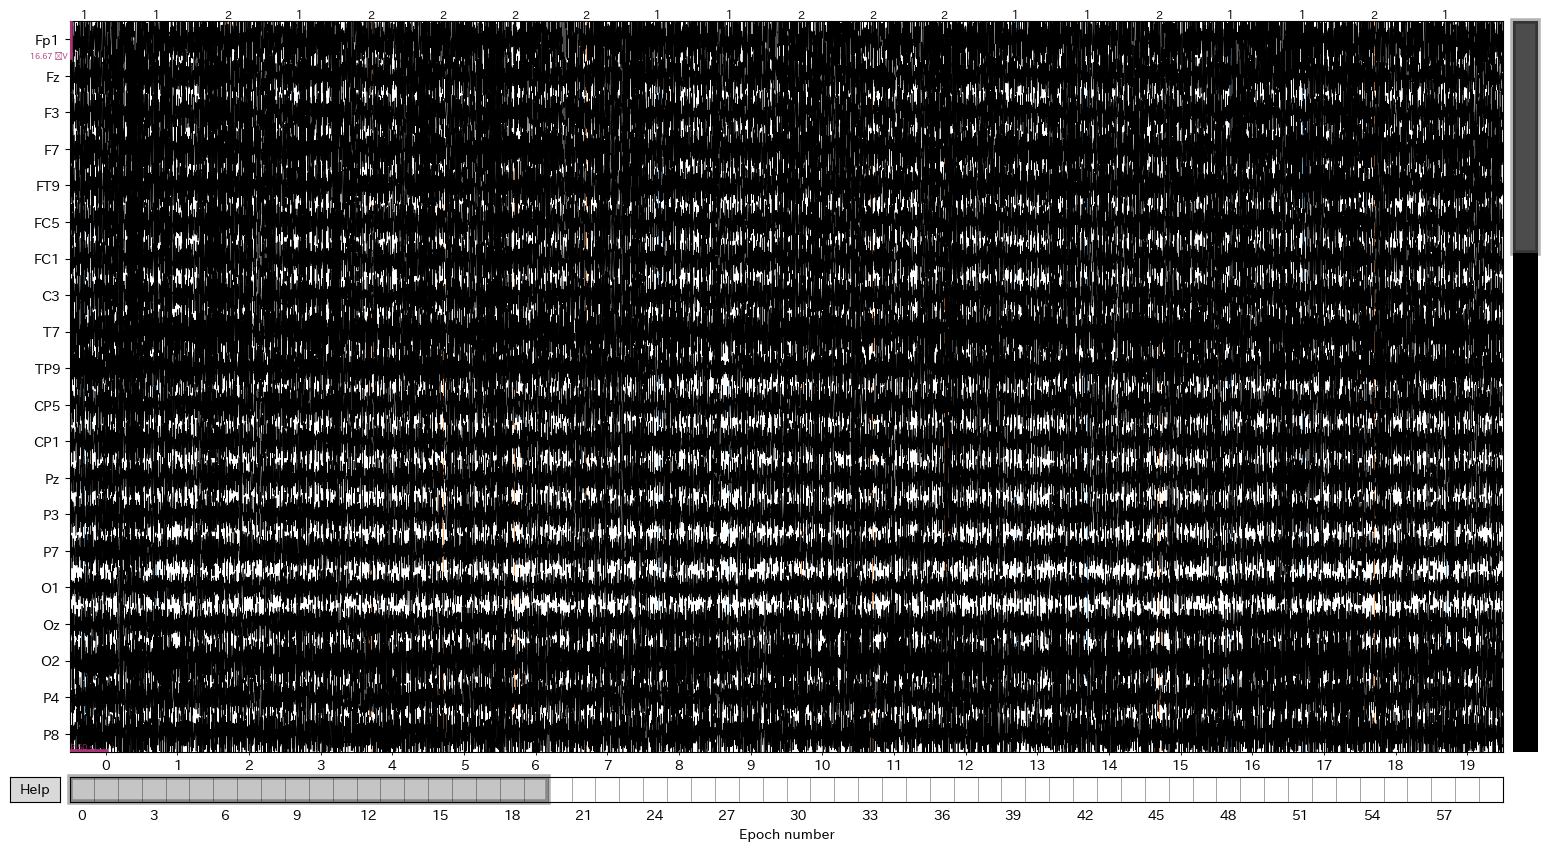

badとしてマークされたエポック数: 0
残りのエポック数: 60


In [ ]:
seq_file_dir = Path("../../data") / "20250604" / "hand3"
seq_file_path = [
    seq_file_dir / "task-sequence1.csv",
    seq_file_dir / "task-sequence2.csv",
    seq_file_dir / "task-sequence3.csv",
]

MI_TASK_DURATION_MS = 3000


# タスク順序を読み込む
task_sequence = []
for seq_file_path in seq_file_path:
    with open(seq_file_path, 'r') as f:
        csv_reader = csv.reader(f)
        next(csv_reader)  # ヘッダー行をスキップ
        for row in csv_reader:
            if len(row) >= 2:  # 2列目が存在することを確認
                try:
                    # 2列目を整数として抽出
                    task_sequence.append(int(row[1]))
                except (ValueError, IndexError):
                    # 整数に変換できない場合やインデックスエラーの場合はスキップ
                    print(f"Invalid data in row: {row}")
                    continue

print(f"{len(task_sequence)=}")

raw_events, _labels = mne.events_from_annotations(raw)
triggers_mask = raw_events[:, 2] == 14
event_timestamps = raw_events[triggers_mask, 0]
print(f"event_timestamps: {event_timestamps} {len(event_timestamps)}")

ignore_timestamps = [1086766, 1087277, 1087786, 1088297, 1088809, 1090859, 1091369, 1092137, 1092650, 1093161]
event_timestamps = [t for t in event_timestamps if t not in ignore_timestamps]

assert len(task_sequence) == len(event_timestamps), "Task sequenceとevent timestampsの長さが一致しません"
events = []
for i, t in enumerate(event_timestamps):
    events.append([t, 0, task_sequence[i]])
    # events.append([t+MI_TASK_DURATION_MS*raw.info['sfreq']/1000.0, 0, 9999])

events = np.array(events, dtype=int)

# mne.viz.plot_events(events, sfreq=raw.info['sfreq'], first_samp=raw.first_samp, show=True, event_id=None)

# (エポック数, チャンネル数, 時間サンプル数)
epochs = mne.Epochs(raw, events, tmin=-1, tmax=4, preload=True)

epochs.resample(500, npad="auto")  # 2500Hzから500Hzにダウンサンプリング

# インタラクティブにエポックを表示してbadエポックをマーキング
# (プロット上でクリックして不良エポックを選択できます)
fig = epochs.plot(scalings="auto", events=events)

# badとしてマークされたエポックの情報を表示
n_dropped = len([log for log in epochs.drop_log if len(log) > 0])
print(f"badとしてマークされたエポック数: {n_dropped}")
print(f"残りのエポック数: {len(epochs)}")

epochs_data = epochs.get_data(copy=True)
labels = epochs.events[:,-1]

In [72]:
epochs_data.shape

(45, 64, 801)

In [73]:
labels.shape

(45,)

Computing rank from data with rank=None


    Using tolerance 4.6e-05 (2.2e-16 eps * 64 dim * 3.2e+09  max singular value)
    Estimated rank (data): 63
    data: rank 63 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 63
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 4.5e-05 (2.2e-16 eps * 64 dim * 3.2e+09  max singular value)
    Estimated rank (data): 63
    data: rank 63 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 63
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 4.7e-05 (2.2e-16 eps * 64 dim * 3.3e+09  max singular value)
    Estimated rank (data): 63
    data: rank 63 computed from 64 data channels with 0 projector

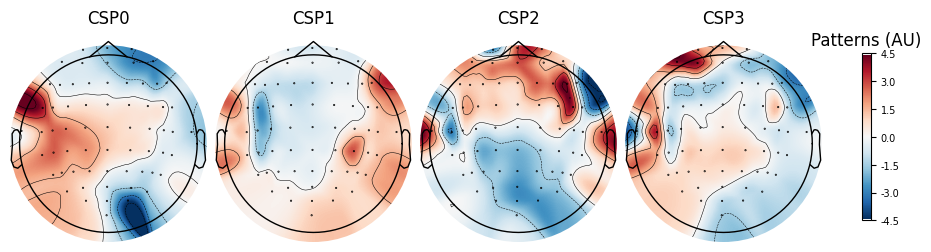

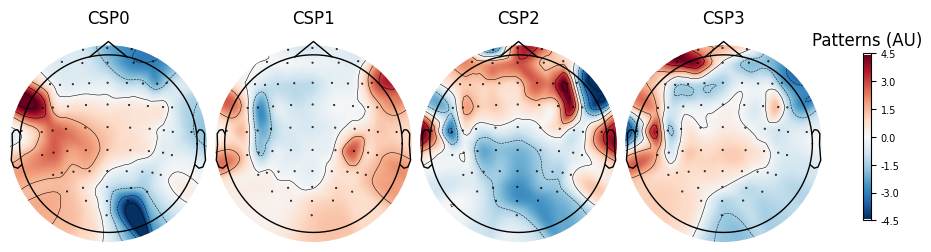

In [74]:
epochs_train = epochs.copy().crop(tmin=0.0, tmax=2.0)  # 2秒間のデータを使用
epochs_train_data = epochs_train.get_data(copy=True)  # エポックデータをリスト形式で取得

# データ型をdouble precision floatに変換（CSPの内部処理でのエラーを防ぐため）
epochs_train_data = epochs_train_data.astype(np.float64)

# Define a monte-carlo cross-validation generator (reduce variance):
scores = []

cv = ShuffleSplit(10, test_size=0.2, random_state=42)
cv_split = cv.split(epochs_train_data)

# Assemble a classifier
lda = LinearDiscriminantAnalysis()
csp = CSP(n_components=4, reg=None, log=True, norm_trace=False,)

# Use scikit-learn Pipeline with cross_val_score function
clf = Pipeline([("CSP", csp), ("LDA", lda)])
scores = cross_val_score(clf, epochs_train_data, labels, cv=cv, n_jobs=None)

# Printing the results
class_balance = np.mean(labels == labels[0])
class_balance = max(class_balance, 1.0 - class_balance)
print(f"Classification accuracy: {np.mean(scores)} / Chance level: {class_balance}")

# plot CSP patterns estimated on full data for visualization
csp.fit_transform(epochs_train_data, labels)

csp.plot_patterns(epochs.info, ch_type="eeg", units="Patterns (AU)", size=1.5)

Computing rank from data with rank=None


    Using tolerance 7.9e-05 (2.2e-16 eps * 64 dim * 5.6e+09  max singular value)
    Estimated rank (data): 63
    data: rank 63 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 63
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 7.9e-05 (2.2e-16 eps * 64 dim * 5.6e+09  max singular value)
    Estimated rank (data): 63
    data: rank 63 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 63
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 7.8e-05 (2.2e-16 eps * 64 dim * 5.5e+09  max singular value)
    Estimated rank (data): 63
    data: rank 63 computed from 64 data channels with 0 projector

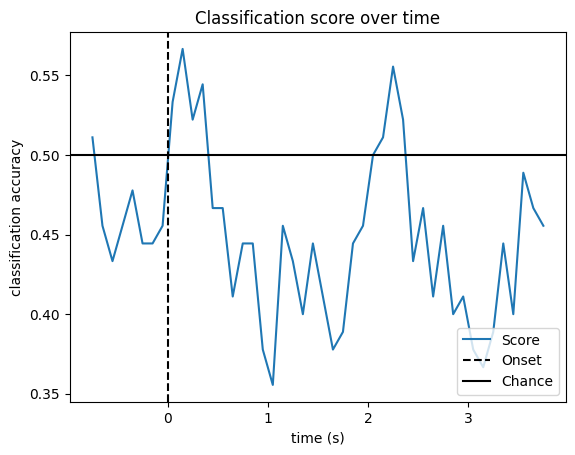

In [75]:
sfreq = epochs.info["sfreq"]
w_length = int(sfreq * 0.5)  # running classifier: window length
w_step = int(sfreq * 0.1)  # running classifier: window step size
w_start = np.arange(0, epochs_data.shape[2] - w_length, w_step)

# データ型を統一してdouble precisionに変換
epochs_data = epochs_data.astype(np.float64)

scores_windows = []

# CVスプリットを再初期化（上のcellで使用したものを再利用）
cv = ShuffleSplit(10, test_size=0.2, random_state=10)
cv_split = cv.split(epochs_data)

for train_idx, test_idx in cv_split:
    y_train, y_test = labels[train_idx], labels[test_idx]

    # トレーニングデータでCSPをフィット
    X_train = csp.fit_transform(epochs_data[train_idx], y_train)
    
    # クラシファイアをフィット
    lda.fit(X_train, y_train)

    # running classifier: test classifier on sliding window
    score_this_window = []
    for n in w_start:
        # スライディングウィンドウのデータを抽出
        window_data = epochs_data[test_idx][:, :, n : (n + w_length)]
        X_test = csp.transform(window_data)
        score_this_window.append(lda.score(X_test, y_test))
    scores_windows.append(score_this_window)

# Plot scores over time
w_times = (w_start + w_length / 2.0) / sfreq + epochs.tmin

plt.figure()
plt.plot(w_times, np.mean(scores_windows, 0), label="Score")
plt.axvline(0, linestyle="--", color="k", label="Onset")
plt.axhline(0.5, linestyle="-", color="k", label="Chance")
plt.xlabel("time (s)")
plt.ylabel("classification accuracy")
plt.title("Classification score over time")
plt.legend(loc="lower right")
plt.show()